In [1]:
from gapminder import gapminder
import seaborn.objects as so
import seaborn as sns
import pandas as pd

/home/carlos/miniconda3/envs/venv_labo_datos/lib/python3.12/site-packages/gapminder/data.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
# 1
datosArgentina = gapminder[gapminder["country"] == "Argentina"]
datosArgentina.head()

,country,continent,year,lifeExp,pop,gdpPercap
48,Argentina,Americas,1952,62.485,17876956,5911.315053
49,Argentina,Americas,1957,64.399,19610538,6856.856212
50,Argentina,Americas,1962,65.142,21283783,7133.166023
51,Argentina,Americas,1967,65.634,22934225,8052.953021
52,Argentina,Americas,1972,67.065,24779799,9443.038526


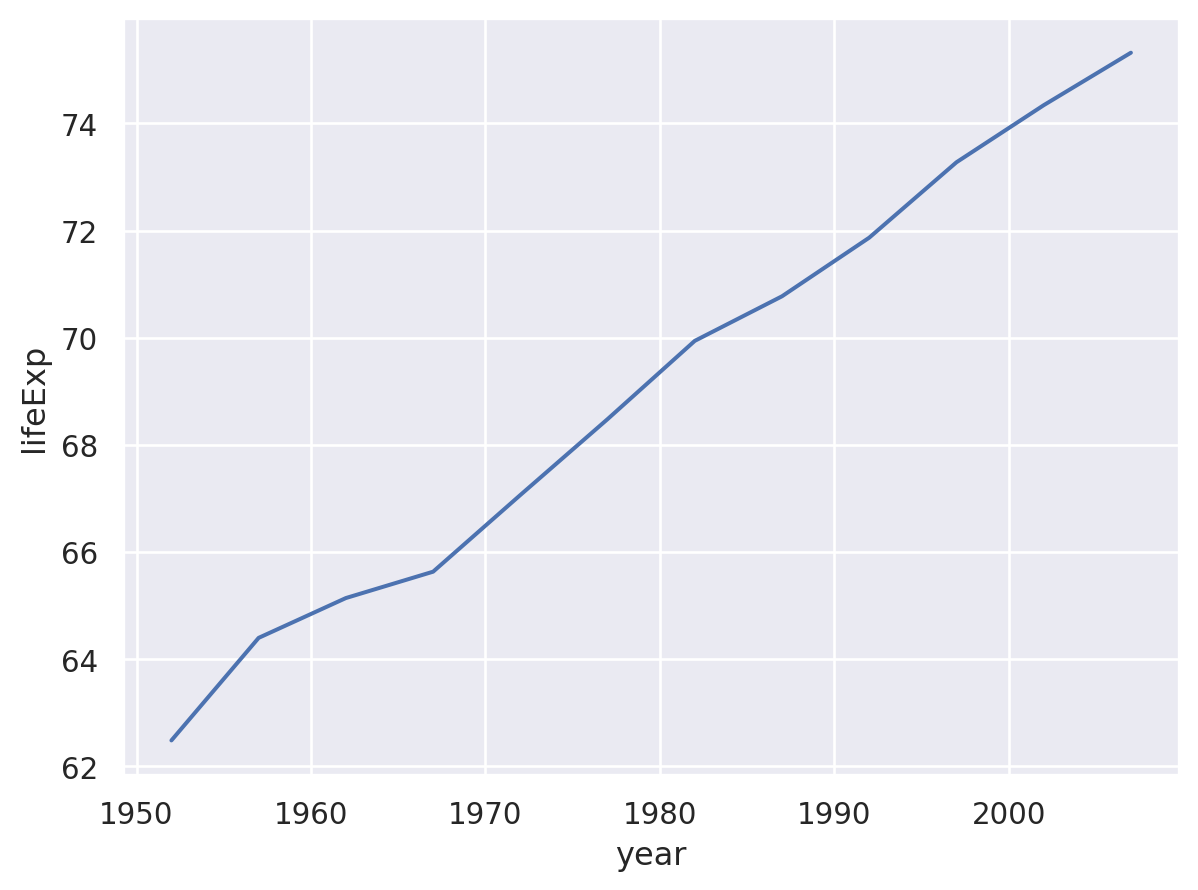

In [3]:
(
    so.Plot(data = datosArgentina, x = "year", y = "lifeExp")
    .add(so.Line())
)

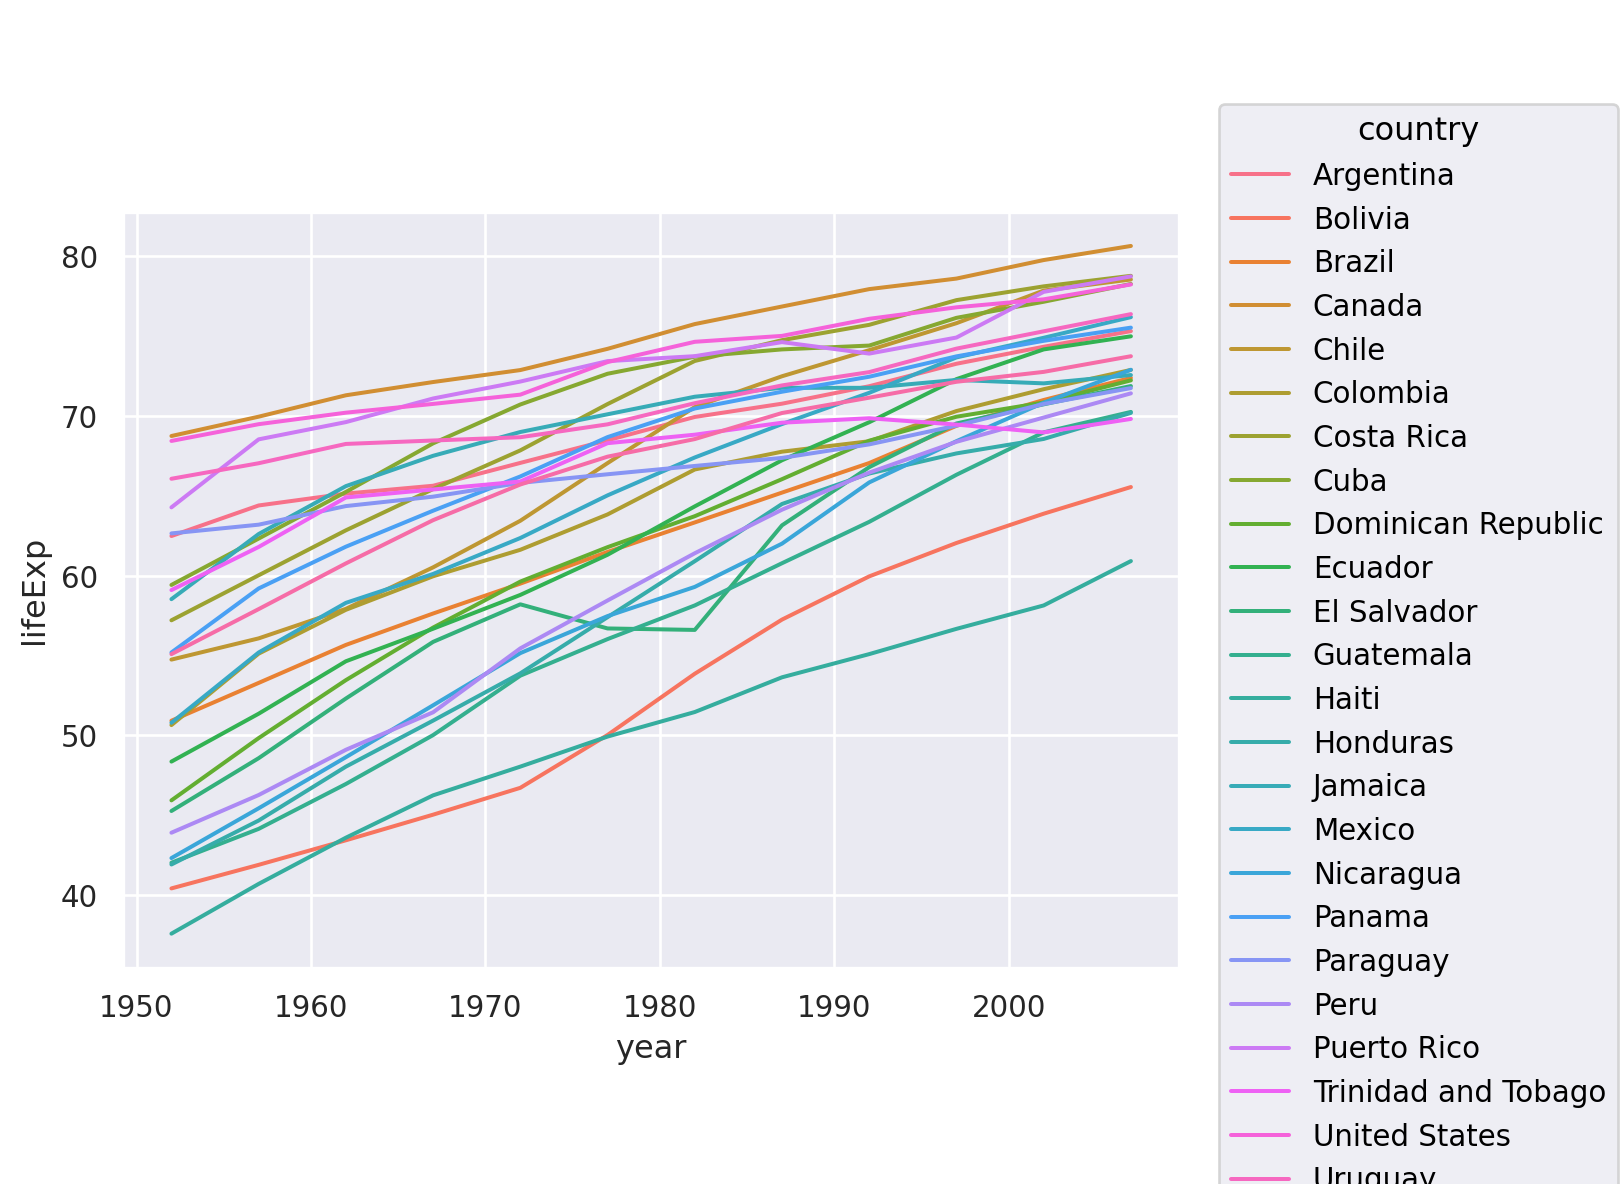

In [4]:
(
    so.Plot(
        data = gapminder[gapminder["continent"] == "Americas"], 
        x = "year", 
        y = "lifeExp", 
        color = "country"
    )
    .add(so.Line())
)
# si se usa group en vez de color, sale el mismo grafico pero todas las lineas tienen el mismo color

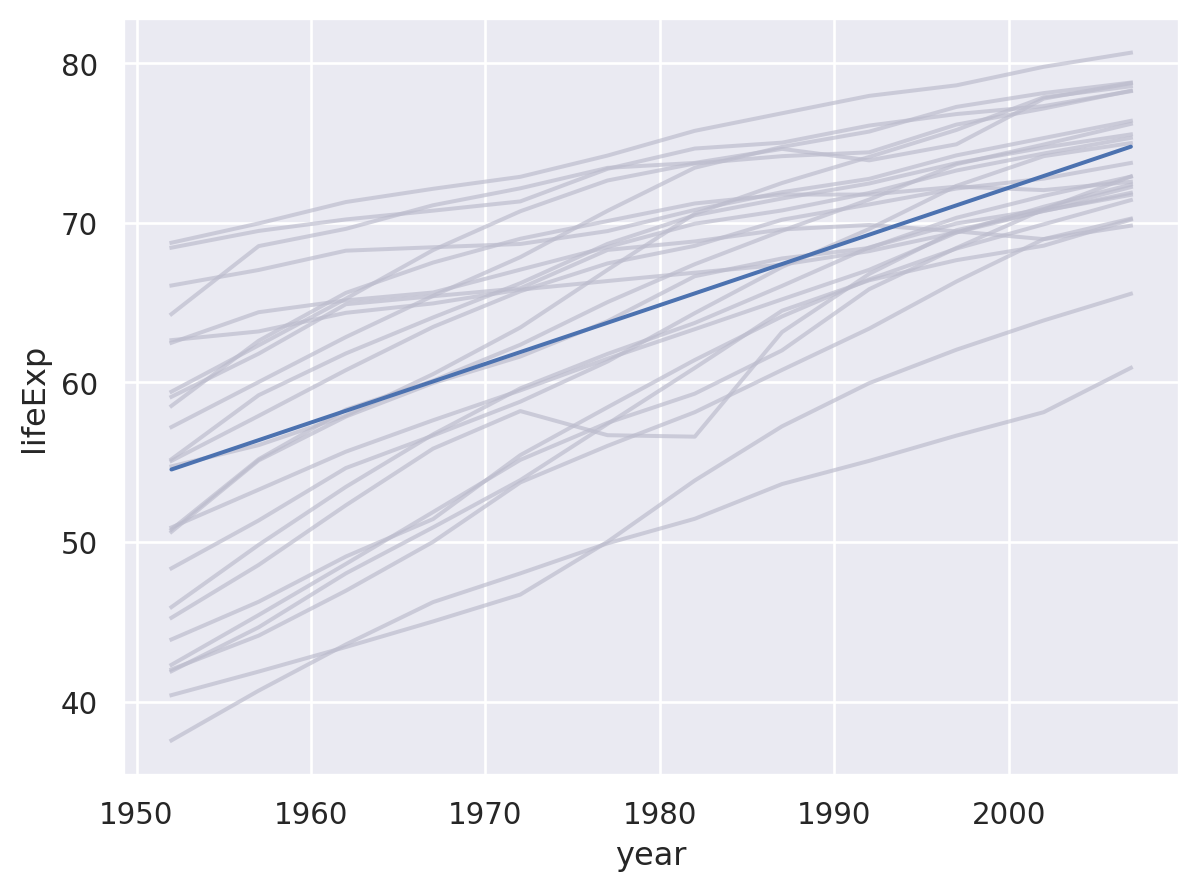

In [5]:
(
    so.Plot(
        data = gapminder[gapminder["continent"] == "Americas"], 
        x = "year", 
        y = "lifeExp"
    )
    .add(so.Lines(color="#bbca"), group = "country")
    .add(so.Line(), so.PolyFit(1))
)
# En este caso, agregando el group en la capa de Lines hace que el ajuste lineal aplique a todos las lineas
# En cambio, si se agrega el group en la capa principal (Plot), el agrupamiento se hace linea por linea

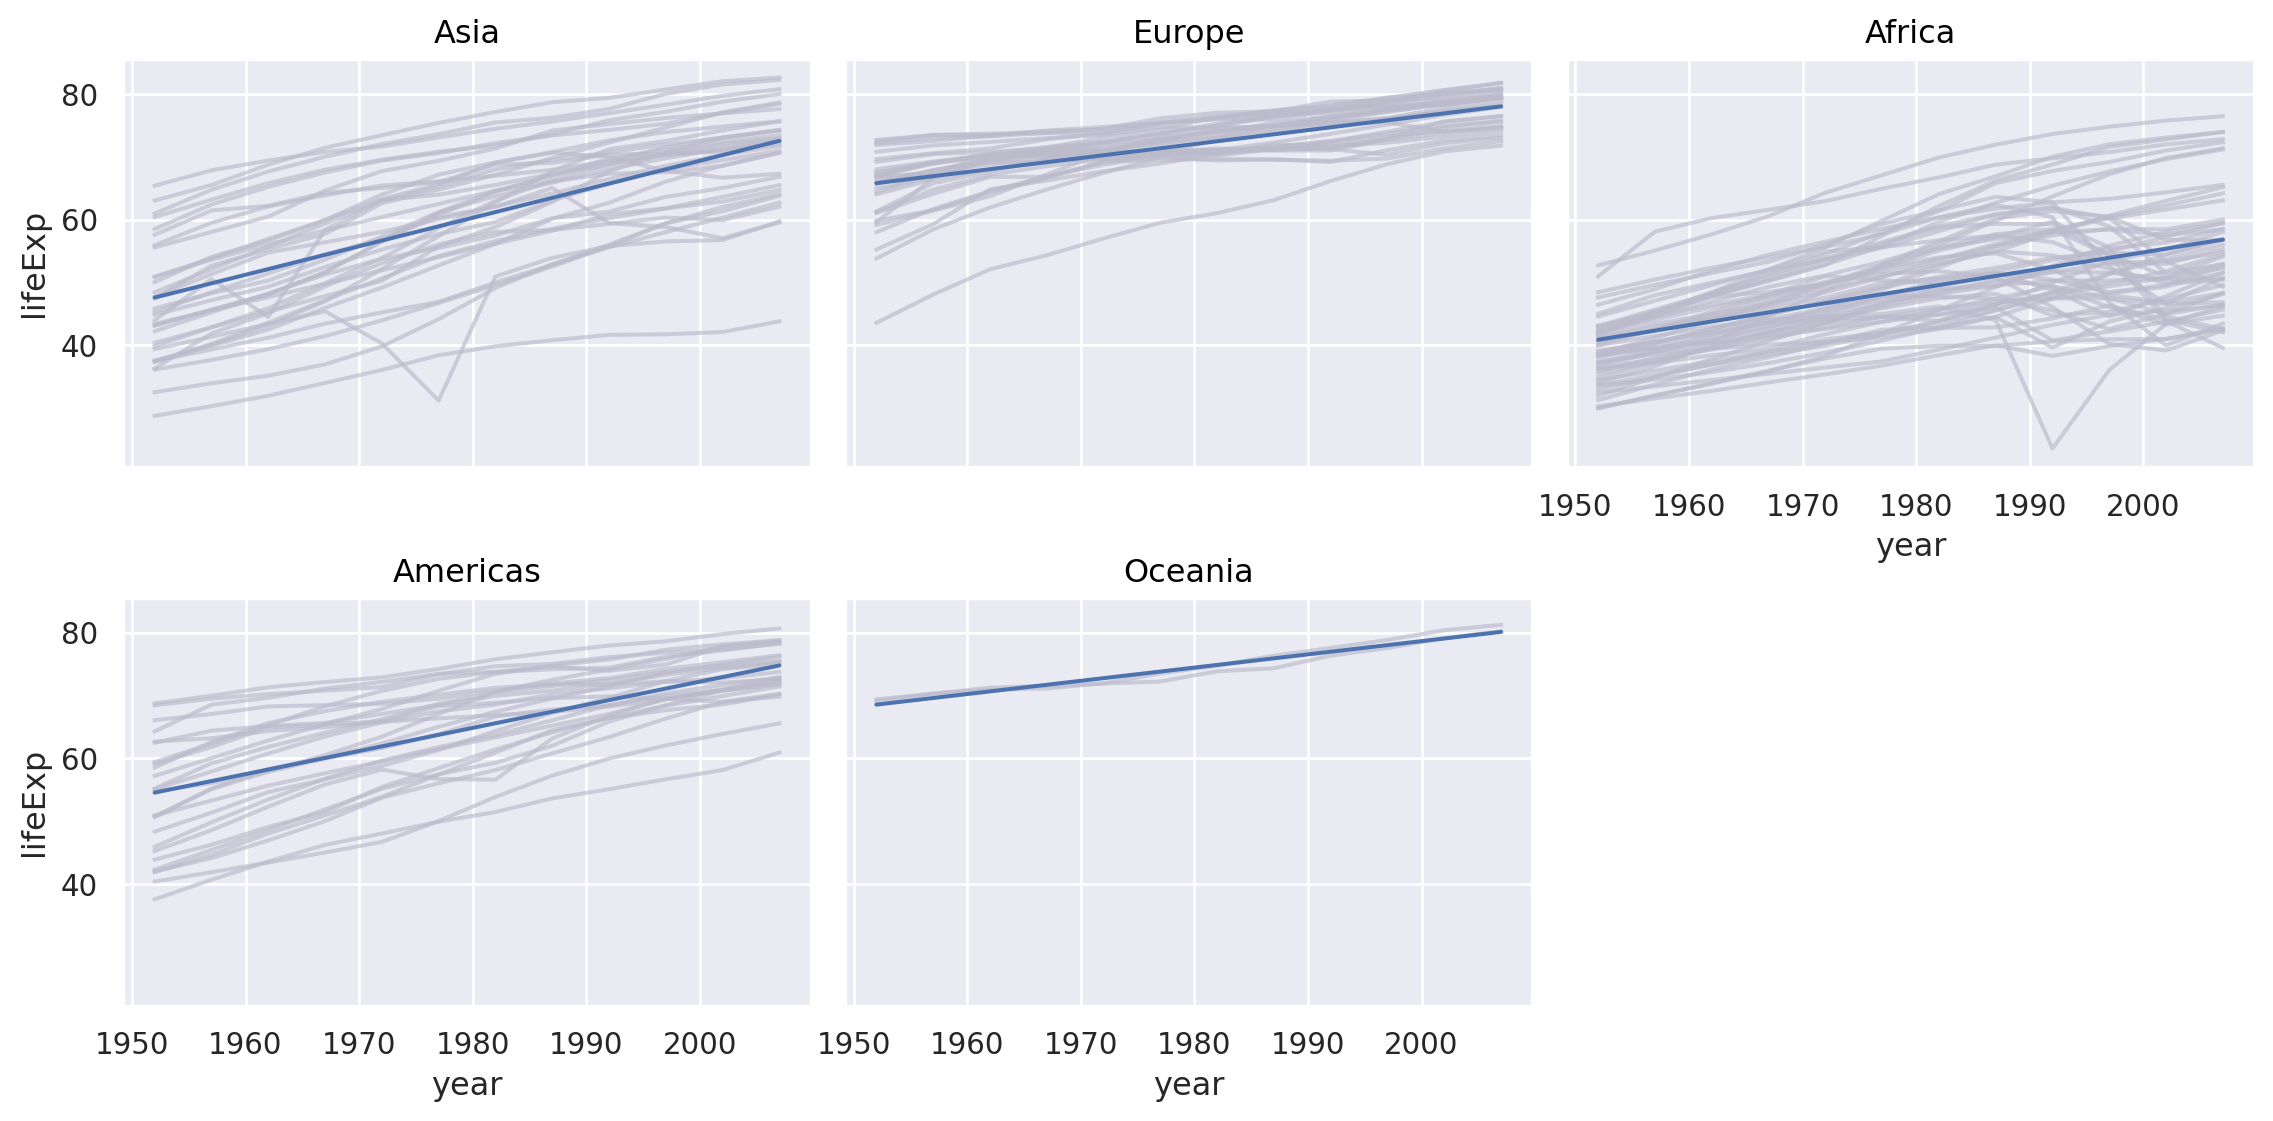

In [6]:
(
    so.Plot (data = gapminder, x = "year", y = "lifeExp")
    .add(so.Lines(color="#bbca"), group="country")
    .add(so.Line(), so.PolyFit(1))
    .facet("continent", wrap = 3)
    .layout(size=(12,6))
)

# facet construye un conjunto de graficos. En este caso se indica que subconjunto va en cada grafico (continent)
# wrap es un entero que indica cuantos graficos se colocan en cada fila de la grilla

In [7]:
# 2
penguins = sns.load_dataset("penguins")

In [8]:
penguins.shape

(344, 7)

In [9]:
# El dataframe penguiins tiene 344 filas y 7 columnas

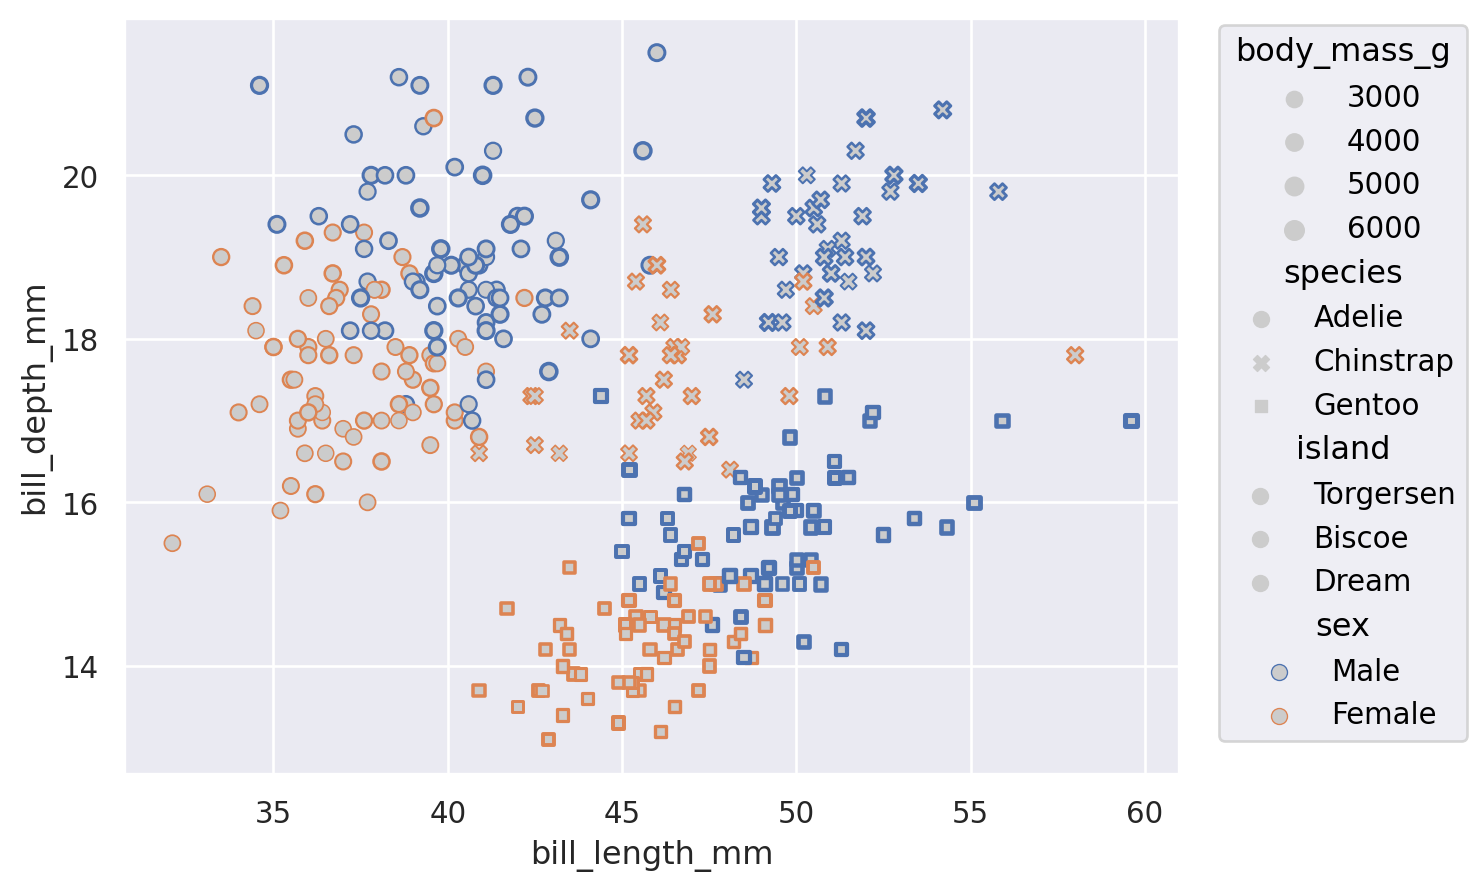

In [10]:
# 3
# De Plot se pasan todas las codificaciones, salvo el color, ya que este se reescribe en la capa Dot
# En Dot se establecen las codificaciones color y edgecolor
# Los puntos van a tener un color particular
(
    so.Plot(
        penguins, x="bill_length_mm", y="bill_depth_mm",
        edgewidth="body_mass_g",
        marker="species",
        linestyle="island",
        color="species"
    )
    .add(so.Dot(color=".8"), edgecolor="sex")
)

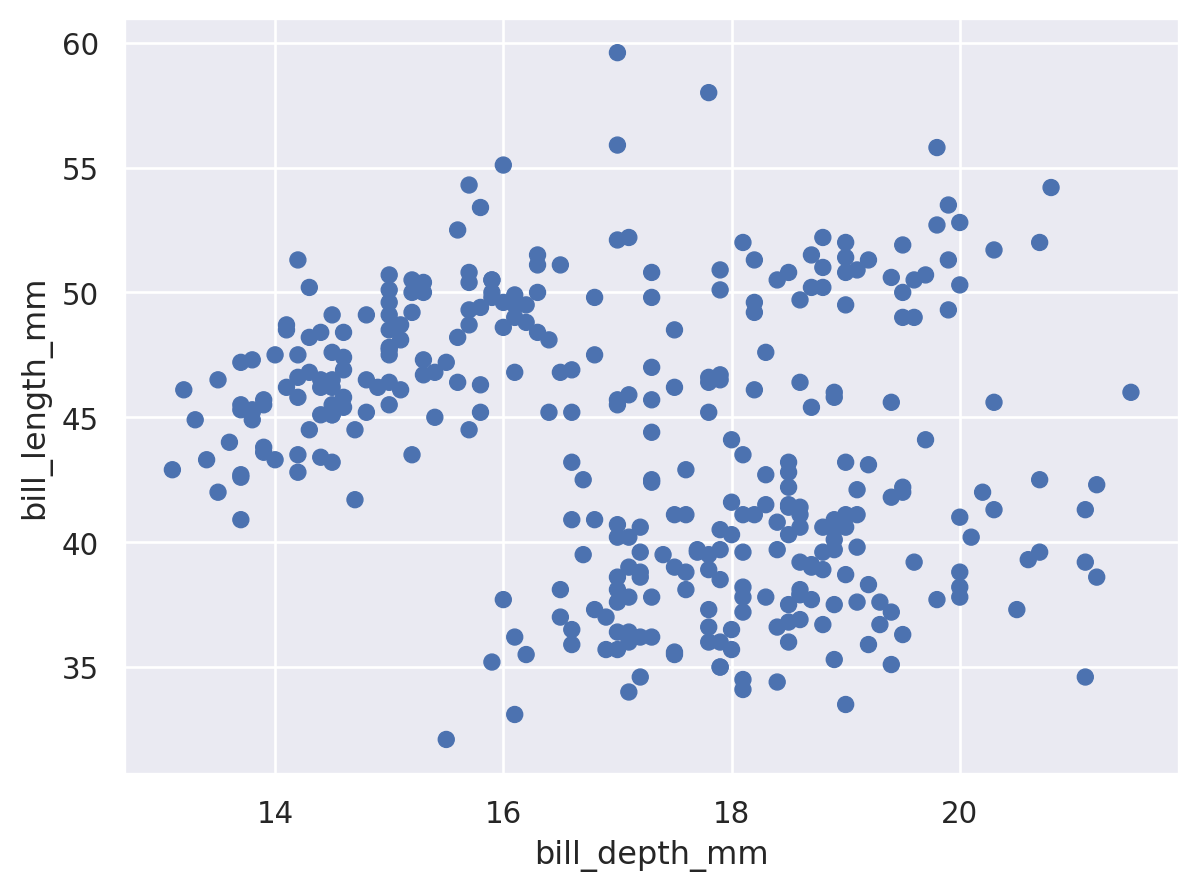

In [11]:
# 4
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm")
    .add(so.Dot())
)

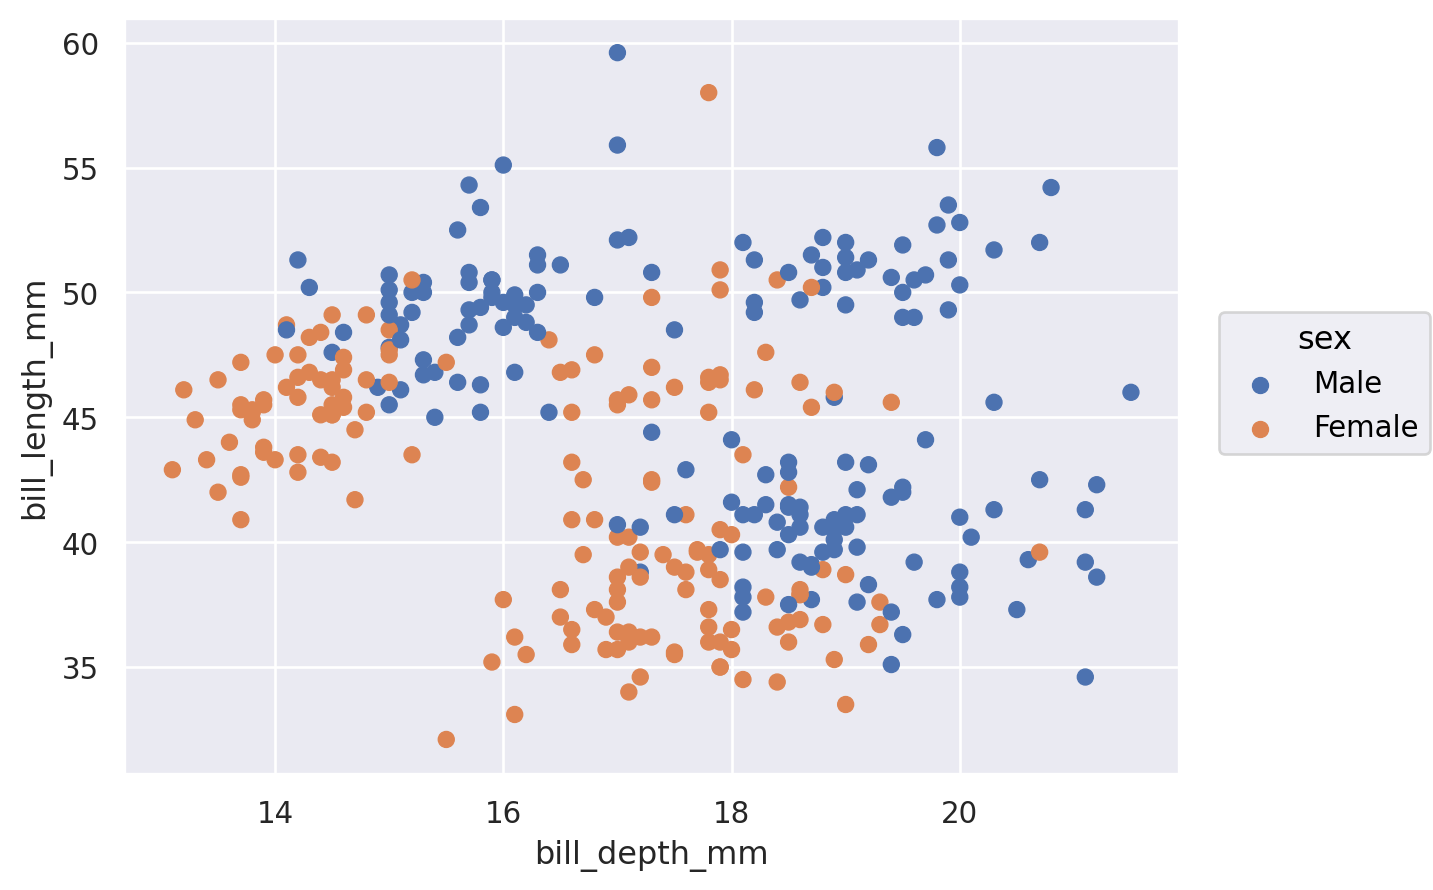

In [12]:
# Puede que haya una distincion en dos grupos: 
# uno con poca profundidad y mucha longitud
# otro con mucha profundidad y poca longitud
# La diferencia podria estar dada por el sexo
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm", color="sex")
    .add(so.Dot())
)

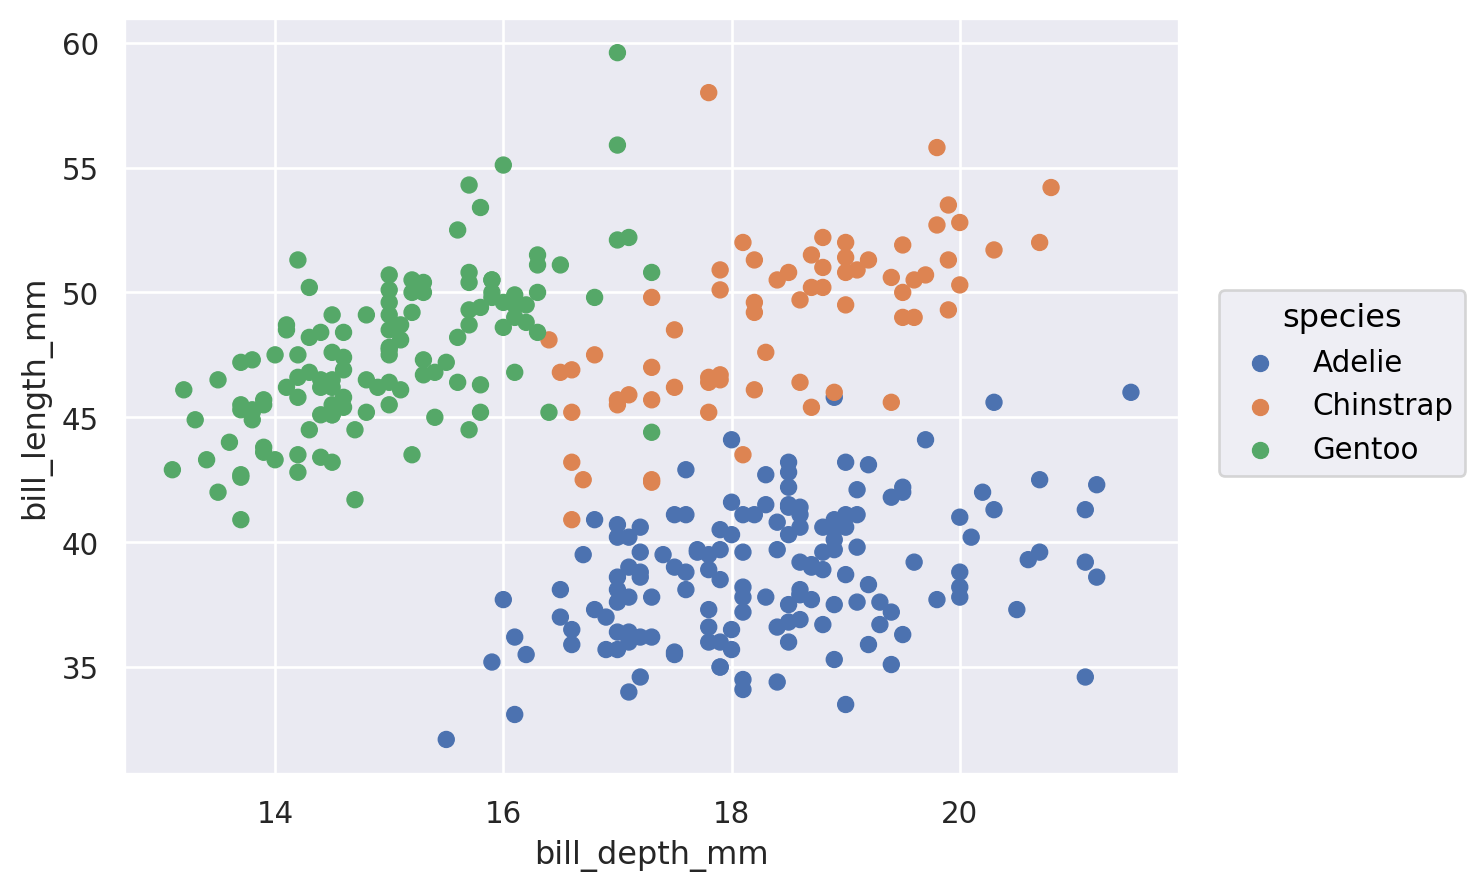

In [13]:
# Otra posibilidad es intentar ver una separacion por especie. Esto se ve mas claro
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm", color="species")
    .add(so.Dot())
)

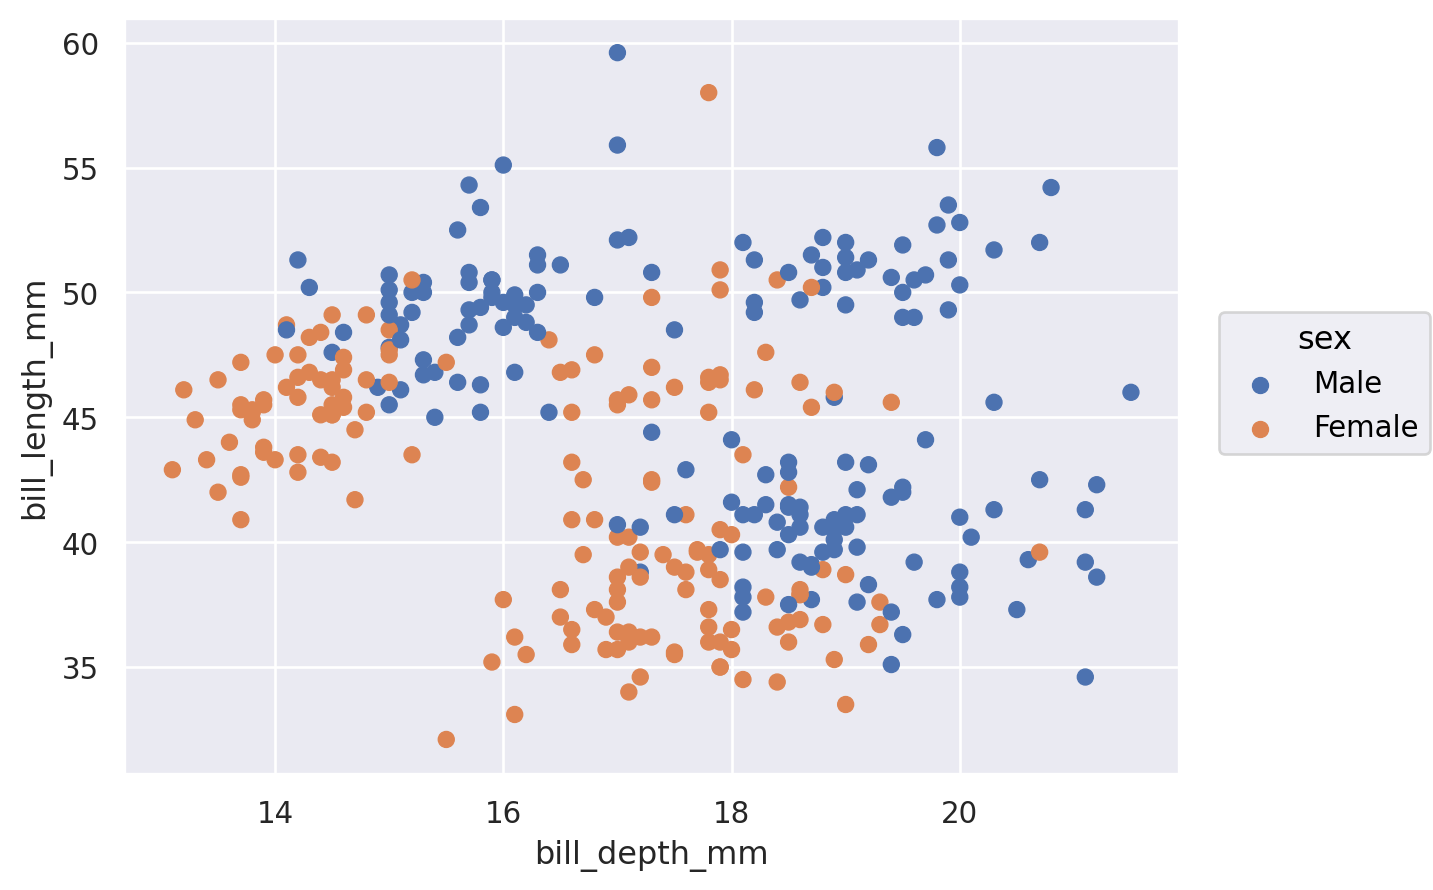

In [14]:
# 5
# Segun sexo se observa que los machos tienen picos mas grandes que las hembras
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm", color="sex")
    .add(so.Dot())
)

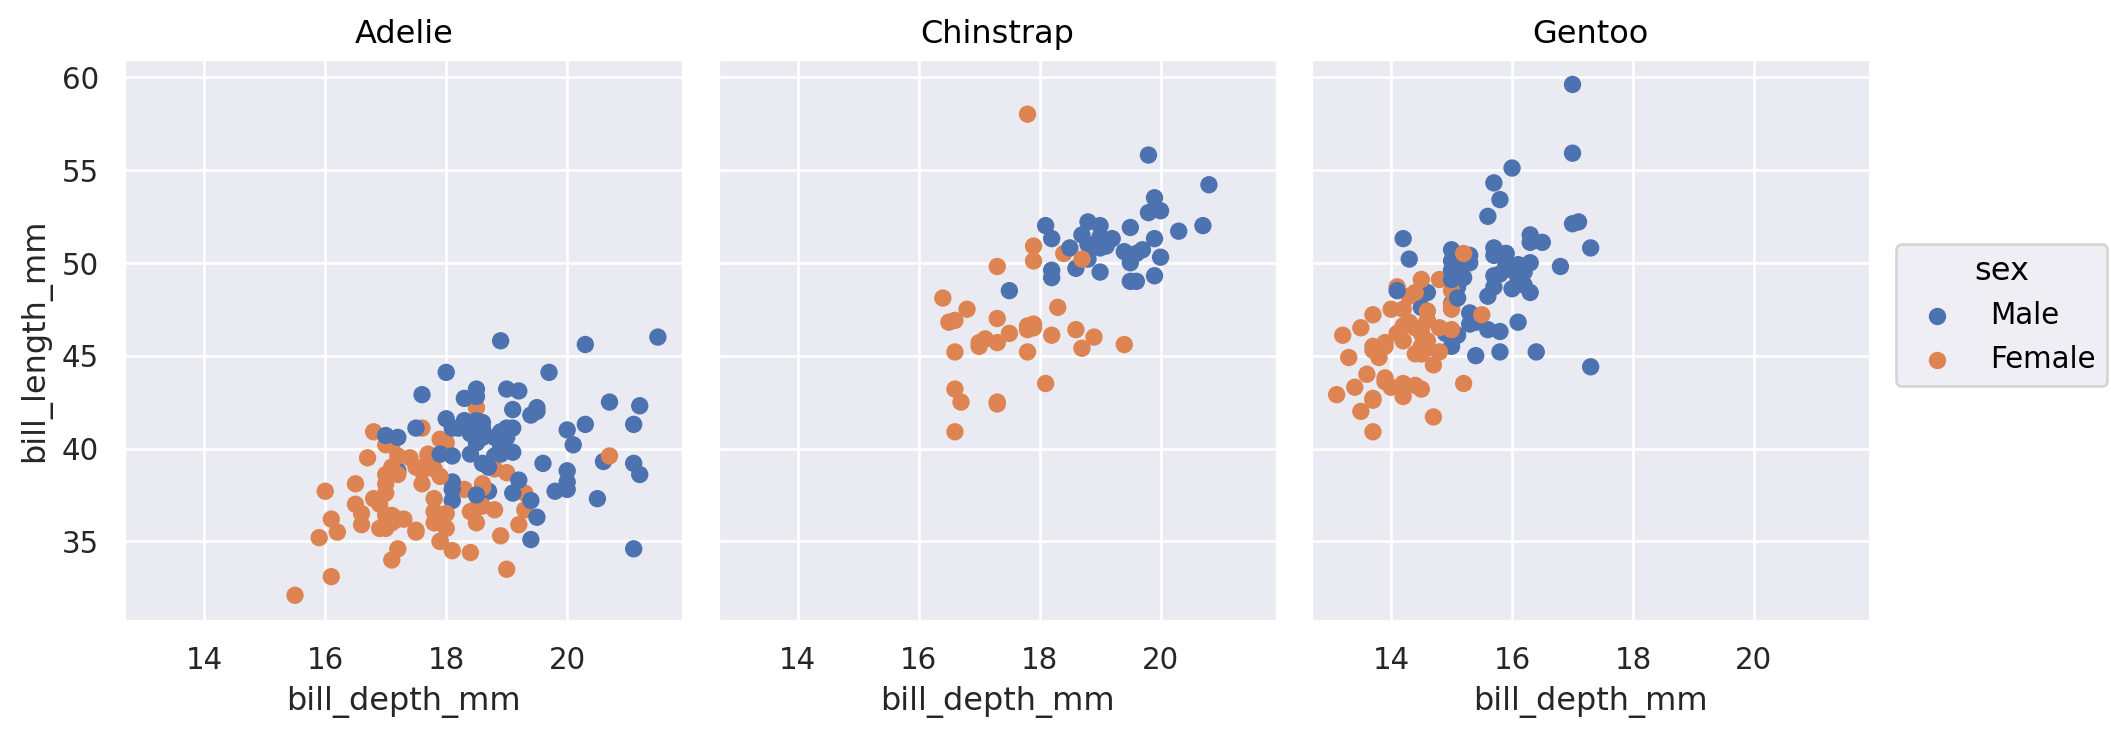

In [15]:
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm", color="sex")
    .add(so.Dot())
    .facet("species")
    .layout(size=(10,4))
)

In [16]:
# 6
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [17]:
pinguinos_por_isla = penguins.groupby("island").size()
pinguinos_por_isla

island
Biscoe       168
Dream        124
Torgersen     52
dtype: int64

In [18]:
pinguinos_por_isla.index

Index(['Biscoe', 'Dream', 'Torgersen'], dtype='object', name='island')

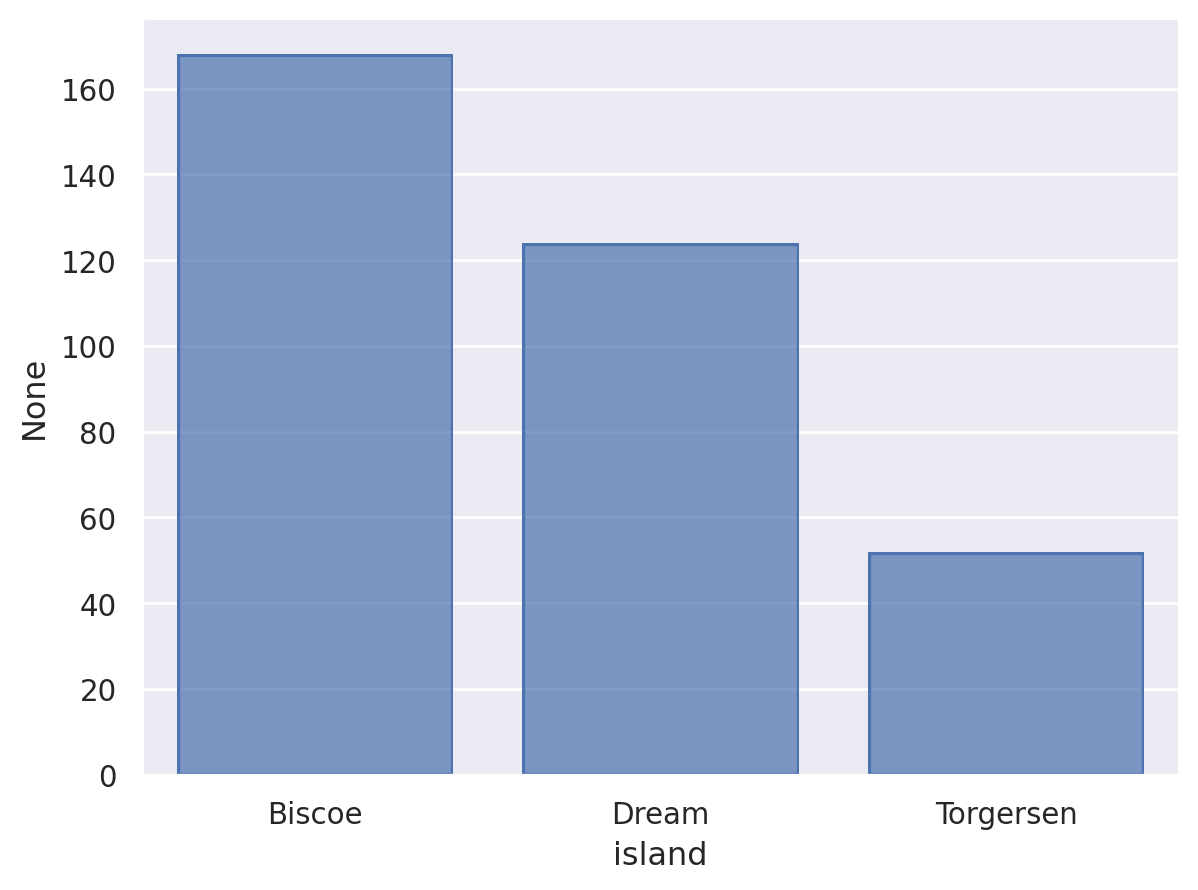

In [19]:
(
    so.Plot(x=pinguinos_por_isla.index, y=pinguinos_por_isla)
    .add(so.Bar())
)

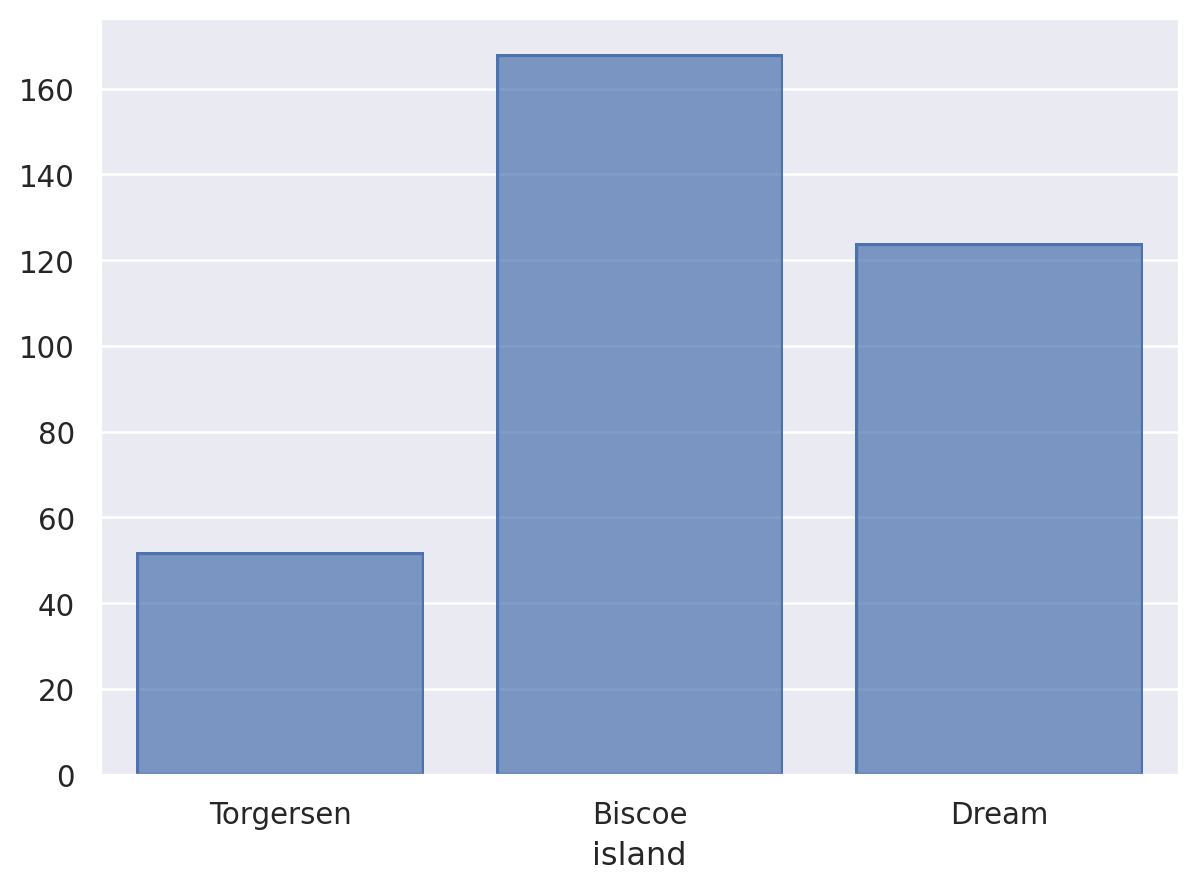

In [20]:
# Usando Hist de seaborn objects
# En este caso no hace falta especificar y, ya que al decir que haga histograma, por defecto hace el size
(
    so.Plot(data=penguins, x="island")
    .add(so.Bar(), so.Hist())
)

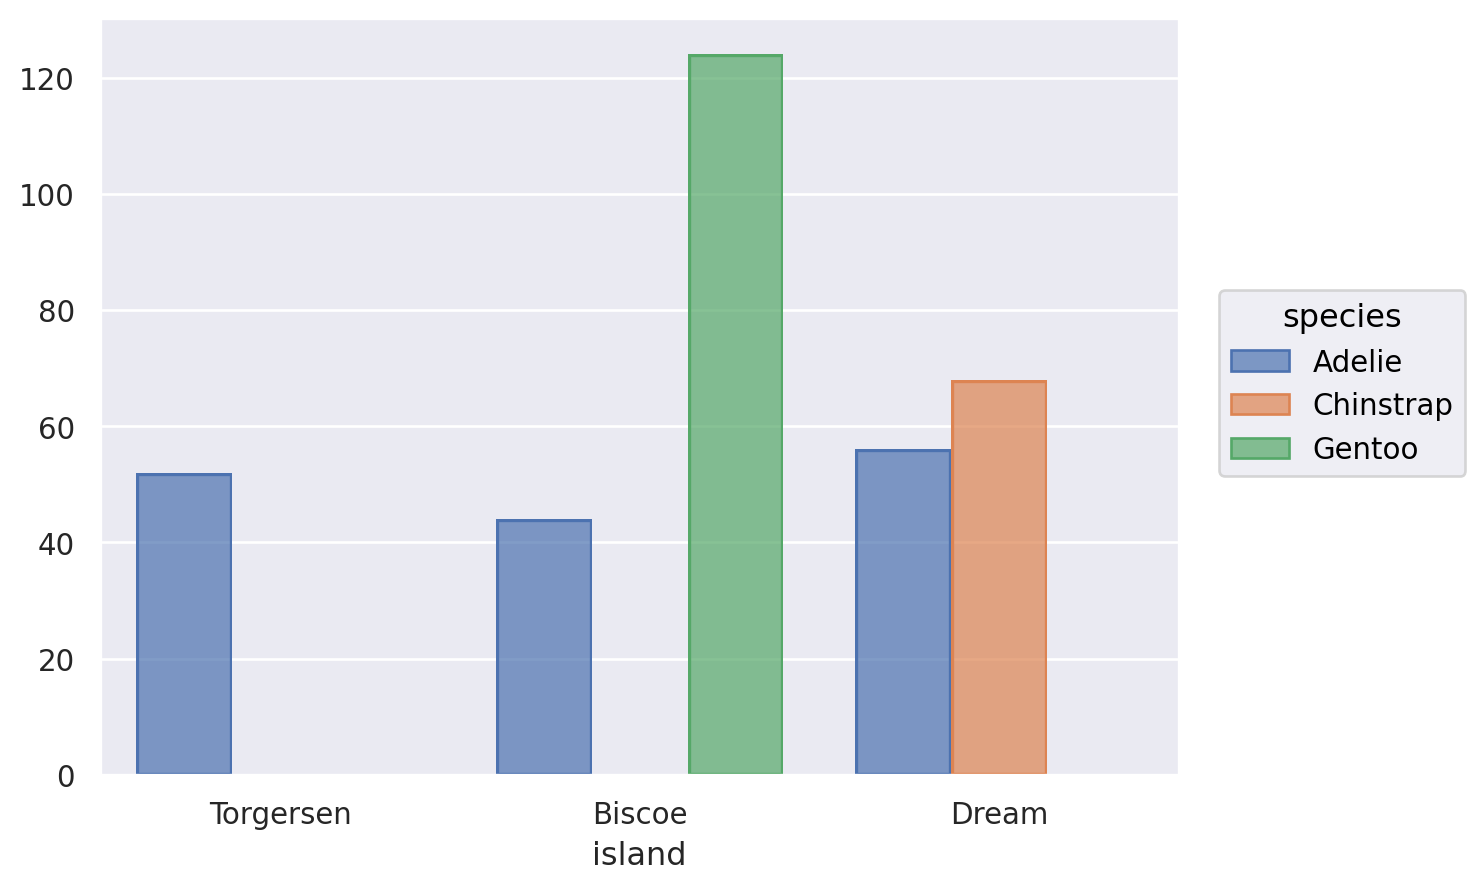

In [21]:
# cuantos pinguinos de cada especie hay en cada isla?
(
    so.Plot(penguins, x="island")
    .add(so.Bar(), so.Hist(), so.Dodge(), color="species")
)

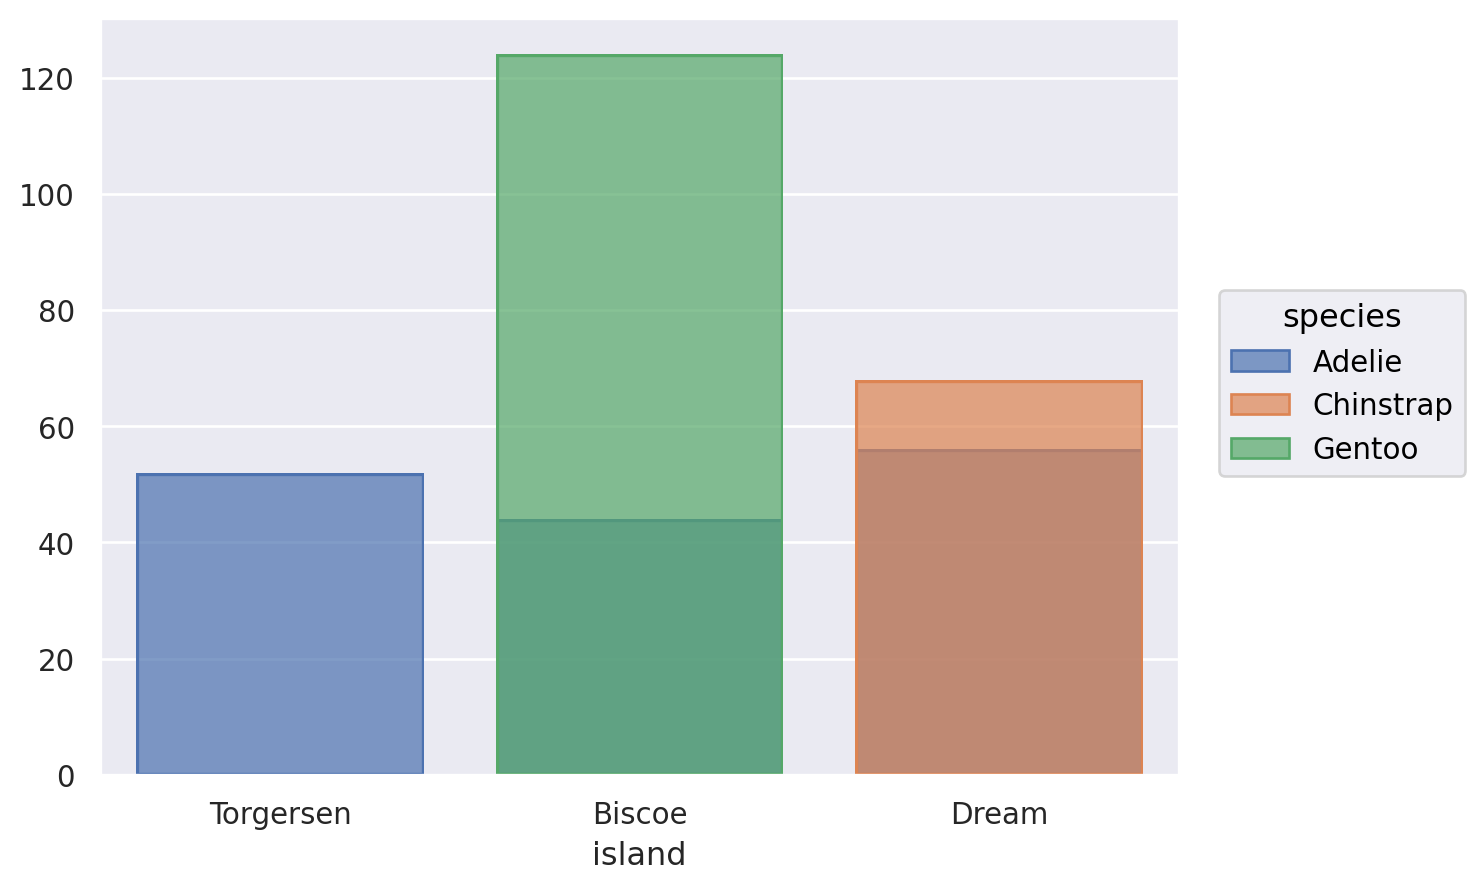

In [22]:
# Si hacemos lo mismo sin el Dodge se mezclarian los colores y no quedaria claro el grafico
(
    so.Plot(penguins, x="island")
    .add(so.Bar(), so.Hist(), color="species")
)

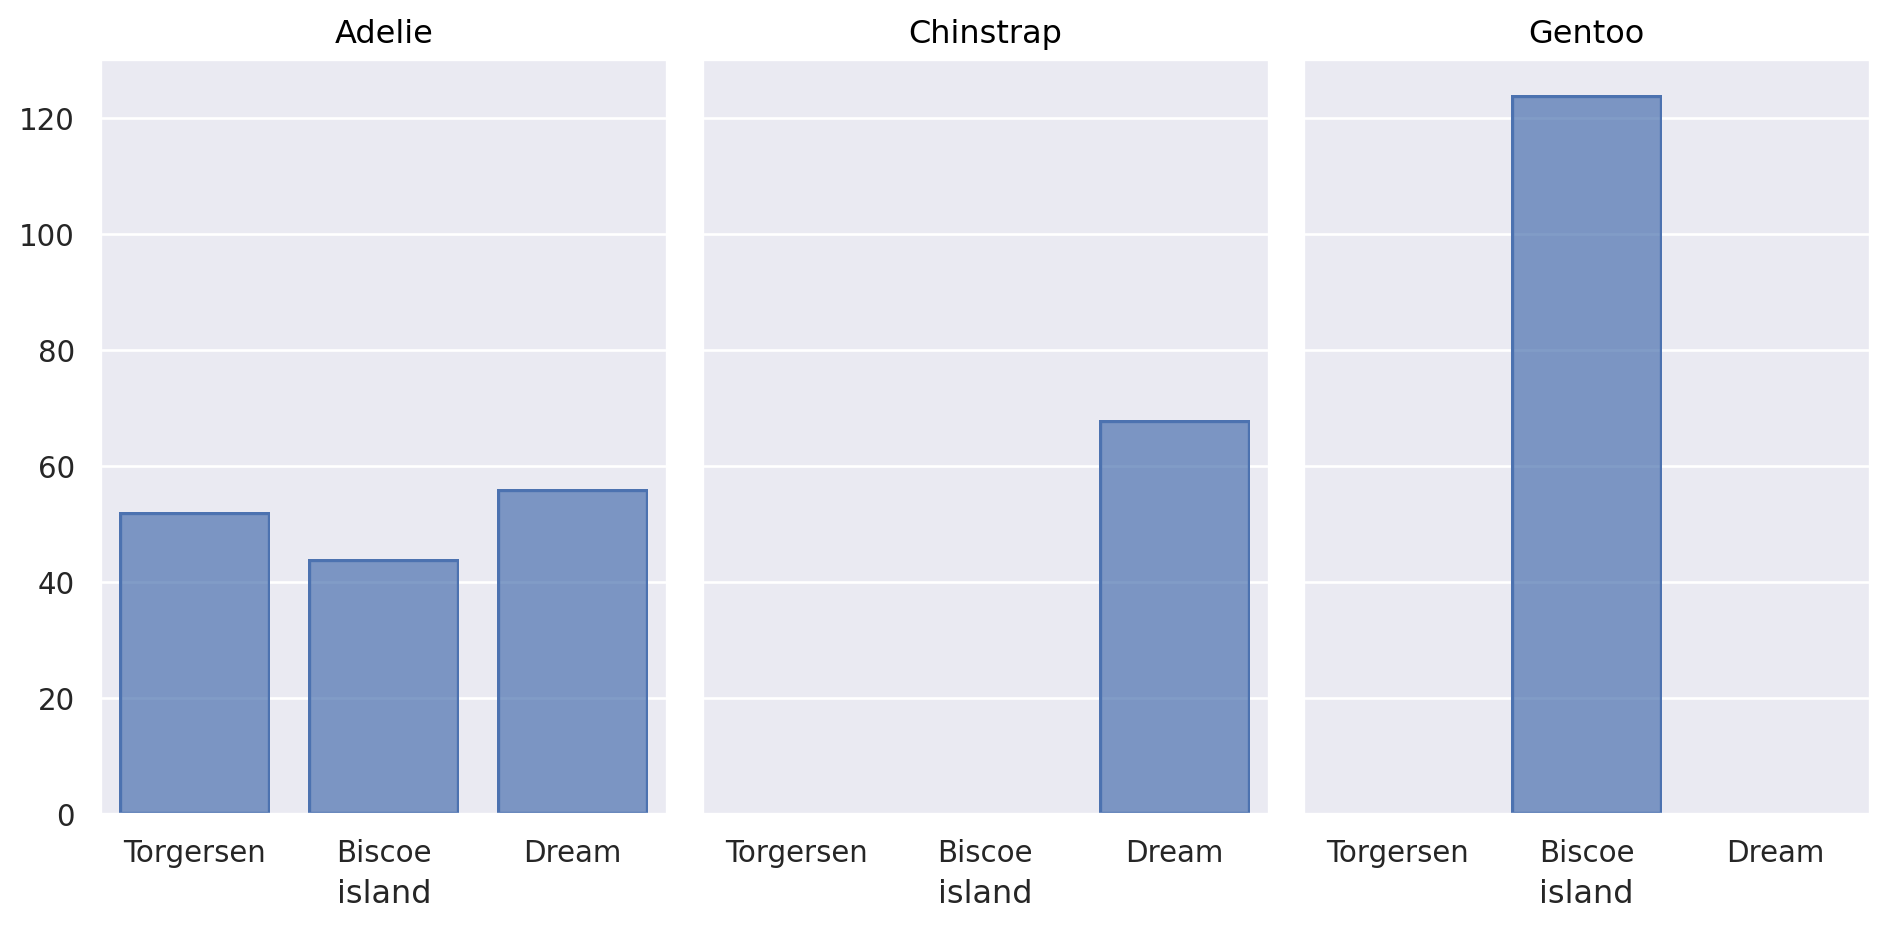

In [23]:
# Usando facet
(
    so.Plot(penguins, x="island")
    .add(so.Bar(), so.Hist())
    .facet("species")
    .layout(size=(10,5))
)

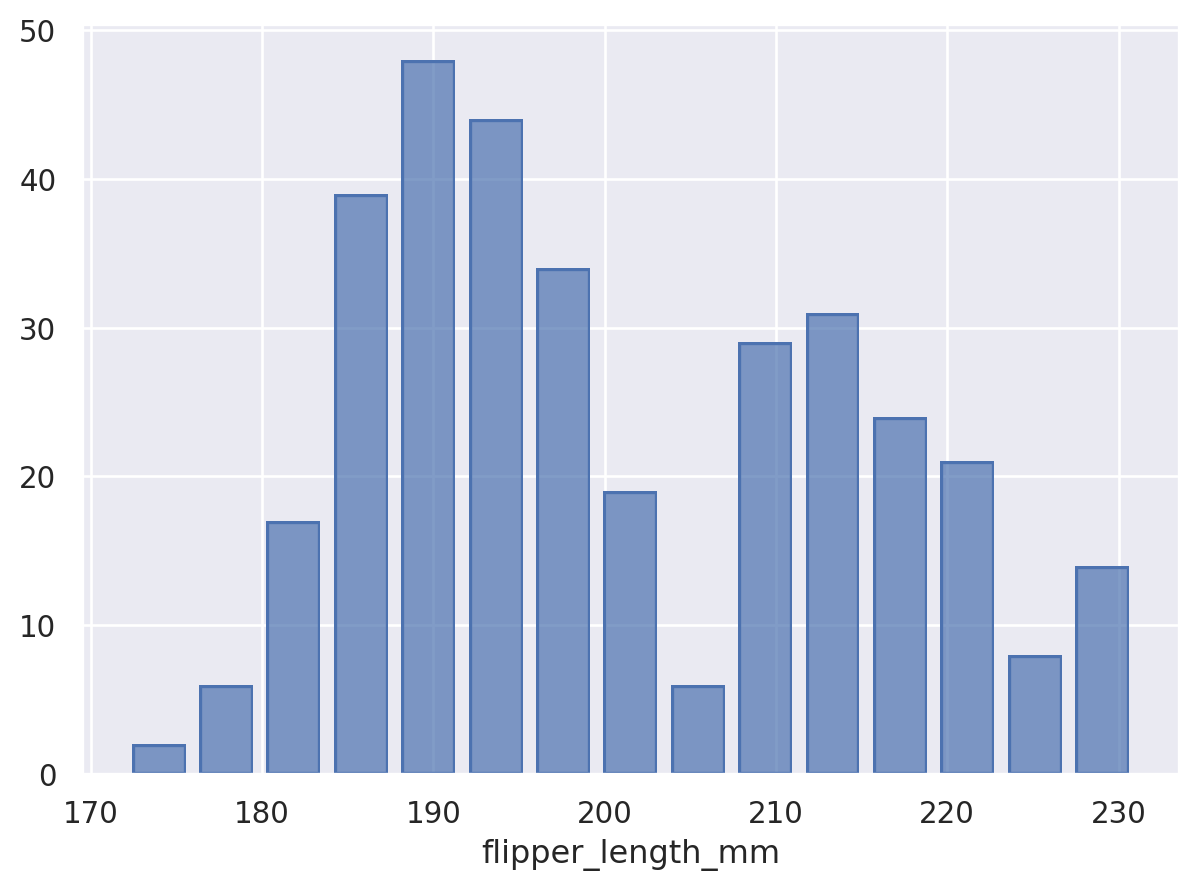

In [24]:
# 7
(
    so.Plot(penguins, x="flipper_length_mm")
    .add(so.Bar(), so.Hist(bins=15))
)

In [25]:
# A partir del grafico:
# minimo: 175
# maximo: 230
# media: 195
# mediana: 202.5

In [26]:
# Calculo para comparar
(
    penguins.flipper_length_mm.min(), 
    penguins.flipper_length_mm.max(), 
    penguins.flipper_length_mm.mean(), 
    penguins.flipper_length_mm.median()
)

(172.0, 231.0, np.float64(200.91520467836258), 197.0)

In [27]:
# 8
(
    penguins.bill_depth_mm.min(), 
    penguins.bill_depth_mm.max(), 
    penguins.bill_depth_mm.mean(), 
    penguins.bill_depth_mm.median()
)

(13.1, 21.5, np.float64(17.151169590643278), 17.3)

<Axes: xlabel='species', ylabel='bill_depth_mm'>

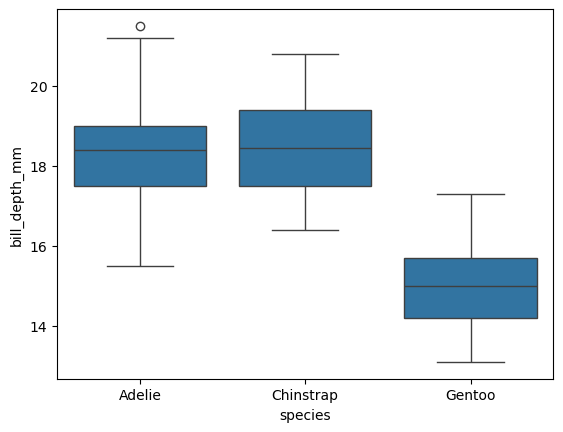

In [28]:
# Segun lo visto en el ejercicio 4, hay variacion, sobre todo en la especie Gentoo
(
    sns.boxplot(penguins, x="species", y="bill_depth_mm")
)

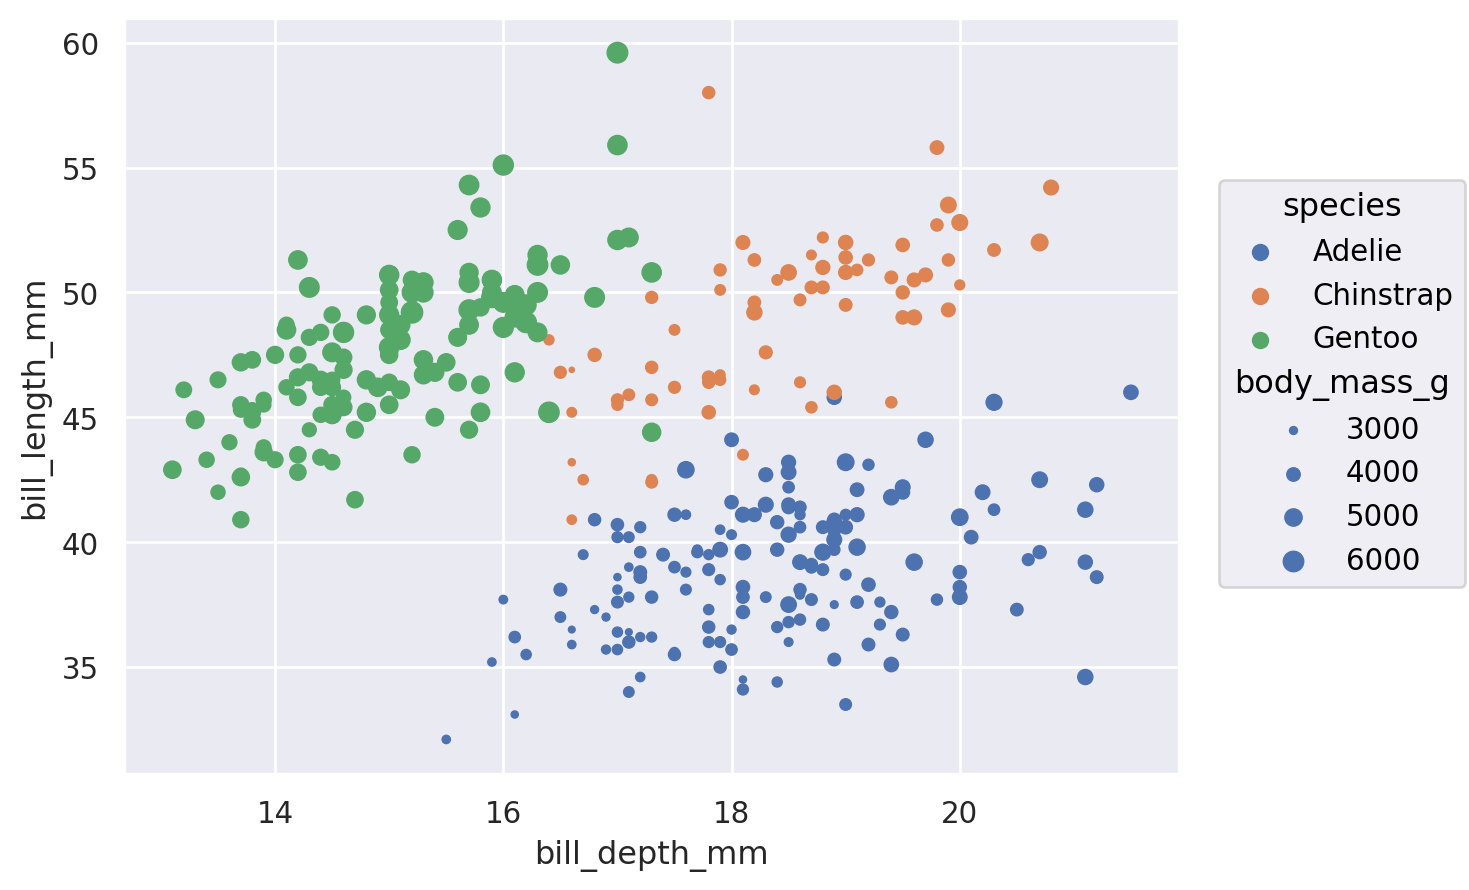

In [29]:
# 9
(
    so.Plot(penguins, x="bill_depth_mm", y="bill_length_mm", color="species")
    .add(so.Dot(), pointsize="body_mass_g")
)
# Se puede observar que los pinguinos de la especie Gentoo son mas pesados

<Axes: xlabel='species', ylabel='body_mass_g'>

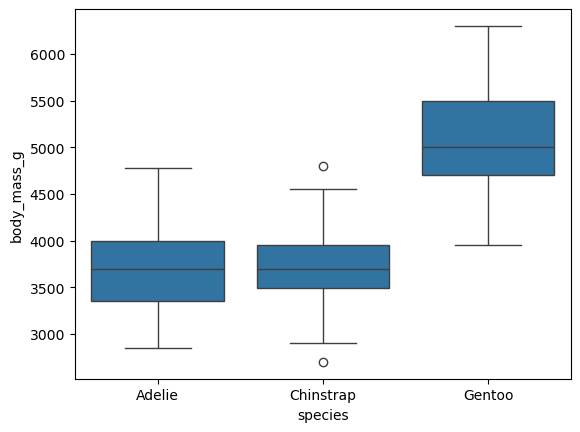

In [30]:
sns.boxplot(penguins, x="species", y="body_mass_g")

In [31]:
# 10
# Grafico de barras

In [32]:
# 11
# Para un dataset con altura, peso y sexo como datos
# Para visualizar cada variable por separado haria un box plot. Esto me daria una idea de como estan distribuidos
# Para visualizar relacion entre peso y altura, haria un grafico de lineas para cada sexo

In [33]:
# 12
gapminder.head()

,country,continent,year,lifeExp,pop,gdpPercap
0,Afghanistan,Asia,1952,28.801,8425333,779.445314
1,Afghanistan,Asia,1957,30.332,9240934,820.853030
2,Afghanistan,Asia,1962,31.997,10267083,853.100710
3,Afghanistan,Asia,1967,34.020,11537966,836.197138
4,Afghanistan,Asia,1972,36.088,13079460,739.981106


In [34]:
continent_grouped = gapminder.groupby("continent").nunique()
continent_grouped

,country,year,lifeExp,pop,gdpPercap
continent,,,,,
Africa,52,12,619,624,624
Americas,25,12,299,300,300
Asia,33,12,393,396,396
Europe,30,12,326,360,360
Oceania,2,12,24,24,24


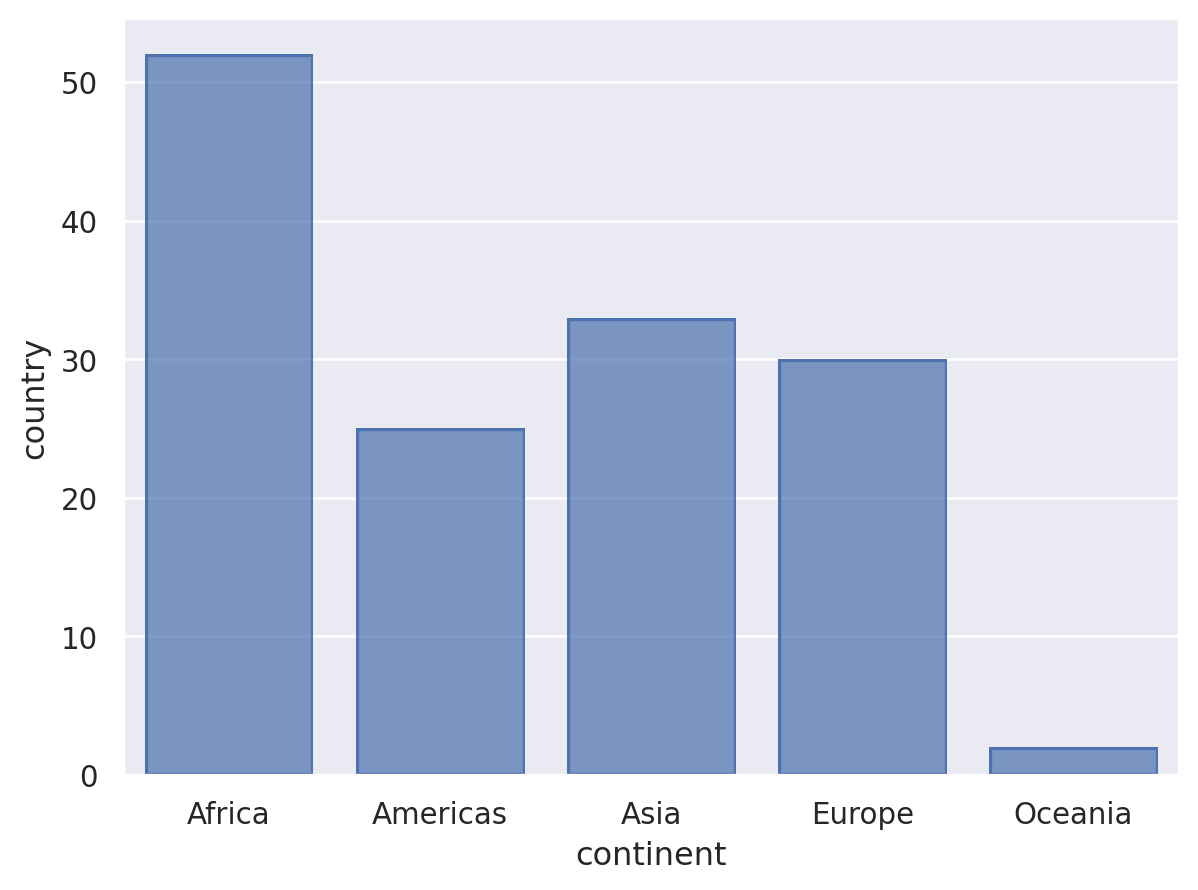

In [48]:
(
    so.Plot(continent_grouped, x = "continent", y = "country")
    .add(so.Bar())
)

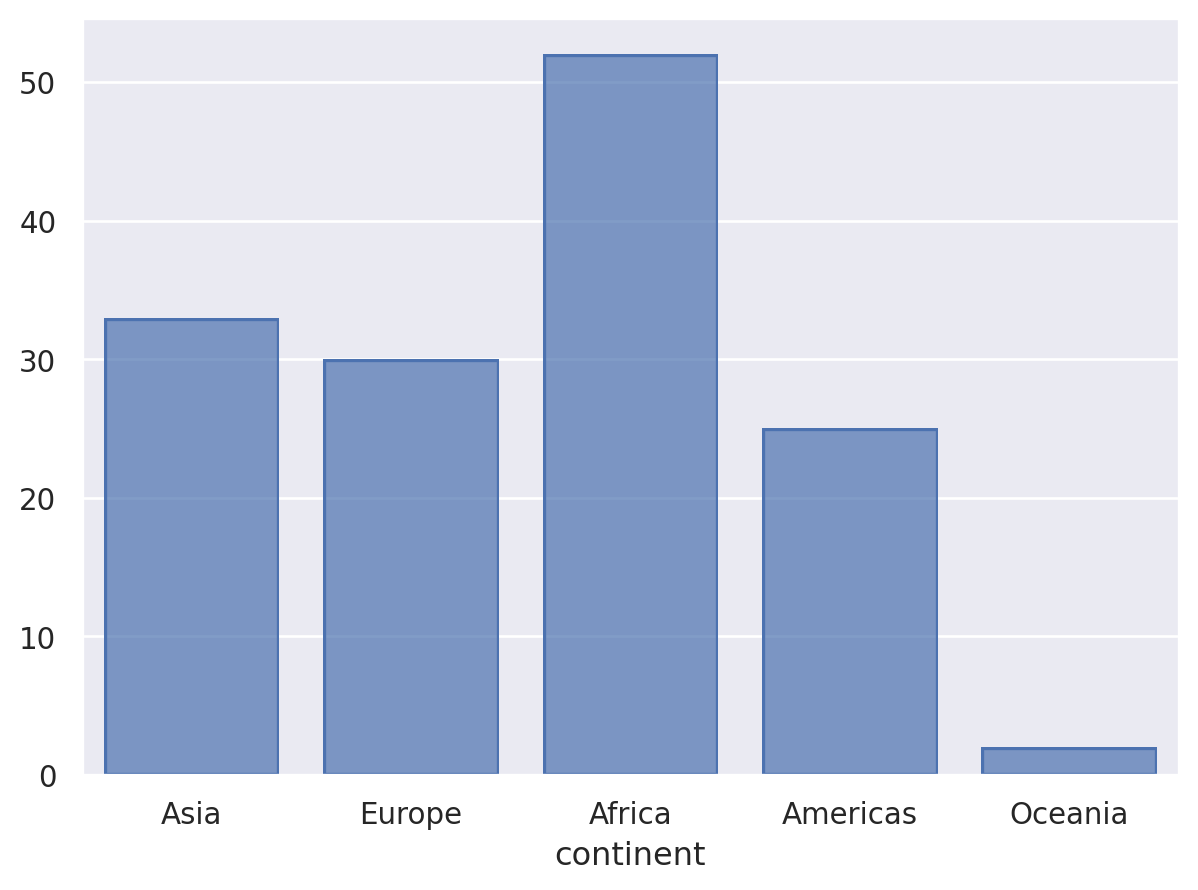

In [54]:
# CONSULTAR!!
# Habia que filtrar por un anio en particular, porque sino cuenta paises de mas
(
    so.Plot(gapminder[gapminder["year"] == 1952], x="continent")
    .add(
        so.Bar(),
        so.Hist(stat="count"),
        # y="country"
    )
)

<Axes: xlabel='continent', ylabel='lifeExp'>

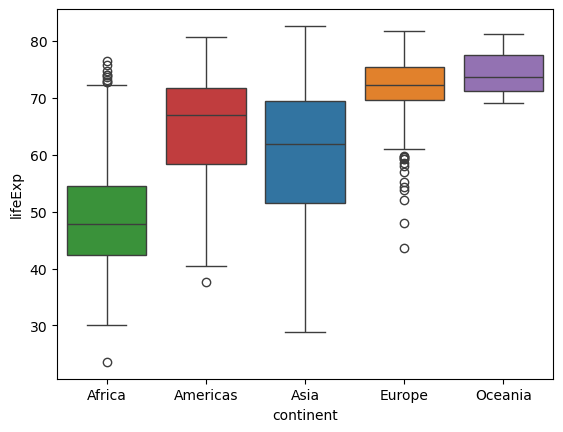

In [37]:
# 13
sns.boxplot(
    gapminder, 
    x = "continent", 
    y = "lifeExp",
    order = sorted(gapminder.continent) ,
    hue = "continent"
)